# 3. Does the outer eddy detect features missed by its centre?

Annuli identify where within the surface ellipse strong topographic gradients occur. The 0.75–1.0 annulus represents the outer core, where a nearby seamount or slope may first intersect the eddy.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import footprint_tools as ft
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}

data = ft.load_cache()
filled = data[(data.footprint_kind == "Filled") & (data.pv_averaging == "nonlinear")].copy()
score = ft.footprint_scorecard(data)


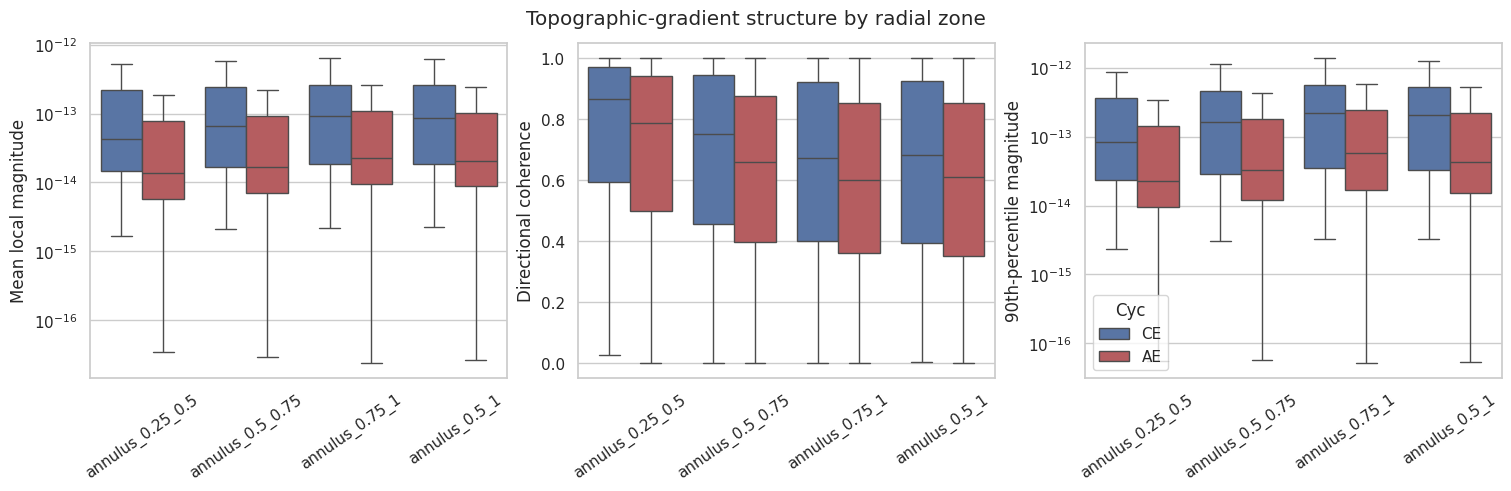

In [2]:
annulus = data[data.footprint_kind.eq("Annulus")].copy()
order = ["annulus_0.25_0.5","annulus_0.5_0.75","annulus_0.75_1","annulus_0.5_1"]
fig, axes = plt.subplots(1,3,figsize=(15,4.8),constrained_layout=True)
for ax,column,label in zip(axes,
    ["PV_grad_topo_mean_local_mag","PV_grad_topo_coherence","PV_grad_topo_p90_local_mag"],
    ["Mean local magnitude","Directional coherence","90th-percentile magnitude"]):
    sns.boxplot(data=annulus,x="footprint",y=column,hue="Cyc",order=order,palette=palette,
                showfliers=False,ax=ax)
    ax.tick_params(axis="x",rotation=35); ax.set(xlabel="",ylabel=label)
    if "magnitude" in label.lower(): ax.set_yscale("log")
    if ax is not axes[-1] and ax.legend_: ax.legend_.remove()
fig.suptitle("Topographic-gradient structure by radial zone"); plt.show()

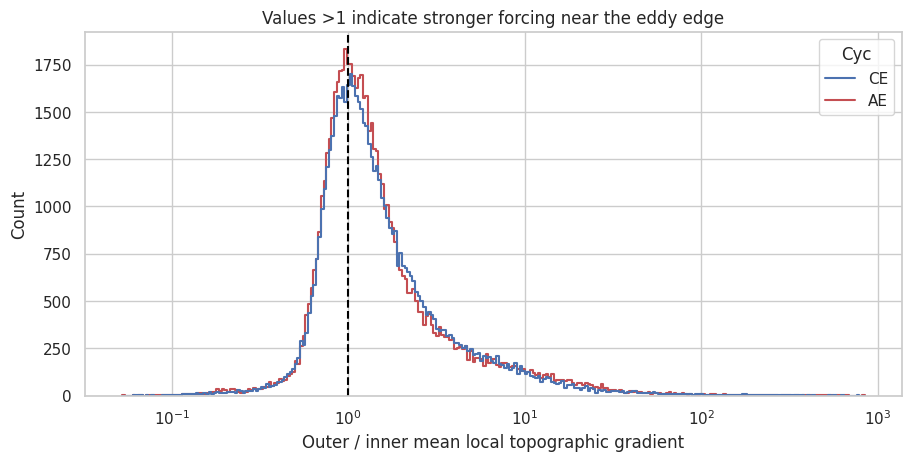

In [3]:
wide = annulus.pivot_table(index=["Eddy","Day","Cyc"],columns="footprint",values="PV_grad_topo_mean_local_mag").reset_index()
wide["outer_inner_ratio"] = wide["annulus_0.75_1"] / wide["annulus_0.25_0.5"]
fig, ax = plt.subplots(figsize=(9,4.5),constrained_layout=True)
sns.histplot(data=wide,x="outer_inner_ratio",hue="Cyc",palette=palette,element="step",fill=False,
             log_scale=True,common_norm=False,ax=ax)
ax.axvline(1,color="black",ls="--"); ax.set(xlabel="Outer / inner mean local topographic gradient",title="Values >1 indicate stronger forcing near the eddy edge"); plt.show()